In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    recall_score, precision_score, fbeta_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
N_OUTER_FOLDS = 5
THRESHOLD_RANGE = np.arange(0.10, 0.91, 0.01)
TEMPORAL_CUTOFF = '2024-01-01'

FINAL_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_rangiwahia_total',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_total',
    'rain_halcombe_maxhr_lag1',
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

RAINFALL_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_maxhr_lag1',
]

OTHER_FEATURES = [
    'rain_rangiwahia_total',
    'rain_halcombe_total',
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('features_labelled.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Label counts:\n{df['label'].value_counts().to_string()}")

X = df[FINAL_FEATURES].copy()
y = df['label'].copy()
print(f"\nX shape: {X.shape} | Unsafe samples: {y.sum()}")

Shape: (485, 60)
Date range: 2005-07-13 to 2026-04-30
Label counts:
label
0.0    408
1.0     77

X shape: (485, 10) | Unsafe samples: 77.0


In [49]:
# ── Pipeline ──────────────────────────────────────────────────────────────────
def make_gb_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer([
        ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
        ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('prep',  preprocessor),
        ('scale', StandardScaler()),
        ('clf',   GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )),
    ])

def find_best_threshold(y_true, y_proba, beta=2.0):
    best_t, best_score = 0.5, -1.0
    for t in THRESHOLD_RANGE:
        y_pred = (y_proba >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score, best_t = score, round(float(t), 2)
    return best_t, best_score

def compute_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'unsafe_recall':     recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'unsafe_precision':  precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f2':                fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_proba),
        'pr_auc':            average_precision_score(y_true, y_proba),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }

print("Pipeline ready.")

Pipeline ready.


In [50]:
# ── 5-Fold Cross Validation ───────────────────────────────────────────────────
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True)
cv_rows = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    gb_pipe = make_gb_pipeline()
    gb_pipe.fit(X_train, y_train)
    gb_proba = gb_pipe.predict_proba(X_val)[:, 1]
    gb_threshold, _ = find_best_threshold(y_val.values, gb_proba)
    gb_metrics = compute_metrics(y_val.values, gb_proba, gb_threshold)
    cv_rows.append({'fold': fold_idx, 'threshold': gb_threshold, **gb_metrics})

    print(f"Fold {fold_idx} | recall={gb_metrics['unsafe_recall']:.3f} "
          f"f2={gb_metrics['f2']:.3f} auc={gb_metrics['roc_auc']:.3f} "
          f"t={gb_threshold:.2f}")

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('gb_cv_results.csv', index=False)
print("\n── CV Summary ──")
print(cv_df[['unsafe_recall','unsafe_precision','f2','roc_auc','balanced_accuracy']].agg(['mean','std']).round(3))

Fold 1 | recall=0.400 f2=0.411 auc=0.746 t=0.32
Fold 2 | recall=0.533 f2=0.556 auc=0.784 t=0.19
Fold 3 | recall=0.667 f2=0.575 auc=0.778 t=0.10
Fold 4 | recall=0.688 f2=0.655 auc=0.873 t=0.11
Fold 5 | recall=0.562 f2=0.500 auc=0.821 t=0.12

── CV Summary ──
      unsafe_recall  unsafe_precision     f2  roc_auc  balanced_accuracy
mean          0.570             0.479  0.539    0.800              0.719
std           0.116             0.132  0.091    0.049              0.053


In [51]:
# ── Tune GB with better hyperparameters ───────────────────────────────────────
from sklearn.model_selection import GridSearchCV

def make_gb_tuned(n_estimators=200, learning_rate=0.05,
                  max_depth=4, subsample=0.8, min_samples_leaf=5):
    preprocessor = ColumnTransformer([
        ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
        ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('prep',  preprocessor),
        ('scale', StandardScaler()),
        ('clf',   GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
        )),
    ])

# Grid search inside CV
param_grid = {
    'clf__n_estimators':    [100, 200],
    'clf__learning_rate':   [0.05, 0.1],
    'clf__max_depth':       [3, 4],
    'clf__min_samples_leaf':[3, 5],
}

outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True)

cv_rows_tuned = []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    gs = GridSearchCV(
        make_gb_tuned(),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1',
        refit=True,
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    best_params = gs.best_params_

    gb_proba = gs.predict_proba(X_val)[:, 1]
    gb_threshold, _ = find_best_threshold(y_val.values, gb_proba)
    gb_metrics = compute_metrics(y_val.values, gb_proba, gb_threshold)
    cv_rows_tuned.append({'fold': fold_idx, 'threshold': gb_threshold, **gb_metrics})

    print(f"Fold {fold_idx} | recall={gb_metrics['unsafe_recall']:.3f} "
          f"f2={gb_metrics['f2']:.3f} auc={gb_metrics['roc_auc']:.3f} "
          f"t={gb_threshold:.2f} | best={best_params}")

cv_tuned_df = pd.DataFrame(cv_rows_tuned)
print("\n── Tuned GB CV Summary ──")
print(cv_tuned_df[['unsafe_recall','unsafe_precision','f2',
                    'roc_auc','balanced_accuracy']].agg(['mean','std']).round(3))

Fold 1 | recall=0.667 f2=0.562 auc=0.757 t=0.11 | best={'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Fold 2 | recall=0.733 f2=0.655 auc=0.828 t=0.10 | best={'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
Fold 3 | recall=0.667 f2=0.617 auc=0.856 t=0.10 | best={'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Fold 4 | recall=0.500 f2=0.482 auc=0.772 t=0.10 | best={'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
Fold 5 | recall=0.688 f2=0.625 auc=0.836 t=0.10 | best={'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}

── Tuned GB CV Summary ──
      unsafe_recall  unsafe_precision     f2  roc_auc  balanced_accuracy
mean          0.651             0.432  0.588    0.810              0.743
std           0.089             0.0

Best params per fold:
  Fold 1: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
  Fold 2: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
  Fold 3: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
  Fold 4: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
  Fold 5: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}

Most common params:
  n_estimators:    200
  learning_rate:   0.05
  max_depth:       3
  min_samples_leaf:5

Hold-out train: (393, 10) | test: (92, 10)
Exceedances in test set: 11

Threshold analysis:
 Threshold |   Caught |   Missed |  False Alarms | Recall
------------------------------------------------------------
  0.05      |  10/11   |   1/11   |   34/81 (42%)    | 91%
  0.08      |  8/11   |   3/1

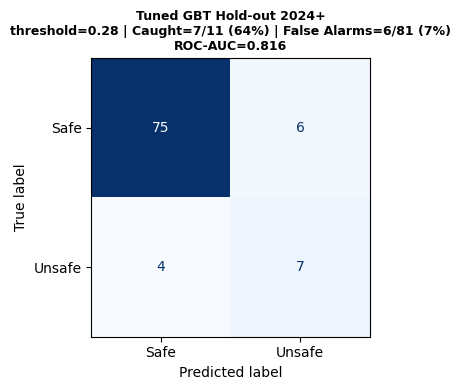

Saved as tuned_gbt_confusion_matrix.png


In [57]:
# ── Final hold-out with best tuned params ──────────────────────────────────
# Get most common best params from CV folds
best_params_list = []
for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    gs = GridSearchCV(
        make_gb_tuned(),
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1',
        refit=True,
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    best_params_list.append(gs.best_params_)

# Print best params per fold
print("Best params per fold:")
for i, p in enumerate(best_params_list, 1):
    print(f"  Fold {i}: {p}")

# Use most common params
from collections import Counter
n_est  = Counter([p['clf__n_estimators'] for p in best_params_list]).most_common(1)[0][0]
lr     = Counter([p['clf__learning_rate'] for p in best_params_list]).most_common(1)[0][0]
depth  = Counter([p['clf__max_depth'] for p in best_params_list]).most_common(1)[0][0]
leaf   = Counter([p['clf__min_samples_leaf'] for p in best_params_list]).most_common(1)[0][0]

print(f"\nMost common params:")
print(f"  n_estimators:    {n_est}")
print(f"  learning_rate:   {lr}")
print(f"  max_depth:       {depth}")
print(f"  min_samples_leaf:{leaf}")

# Build final tuned pipeline
preprocessor_tuned = ColumnTransformer([
    ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
    ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
], remainder='drop')

gb_tuned_final = Pipeline([
    ('prep',  preprocessor_tuned),
    ('scale', StandardScaler()),
    ('clf',   GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=depth,
        min_samples_leaf=leaf,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )),
])

# Train on full training set
train_mask = df.index < TEMPORAL_CUTOFF
X_ho_train_t = X[train_mask]
X_ho_test_t  = X[~train_mask]
y_ho_train_t = y[train_mask]
y_ho_test_t  = y[~train_mask]

gb_tuned_final.fit(X_ho_train_t, y_ho_train_t)
gb_tuned_proba = gb_tuned_final.predict_proba(X_ho_test_t)[:, 1]

# Evaluate at multiple thresholds
print(f"\nHold-out train: {X_ho_train_t.shape} | test: {X_ho_test_t.shape}")
print(f"Exceedances in test set: {int(y_ho_test_t.sum())}")

print(f"\nThreshold analysis:")
print(f"{'Threshold':>10} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 60)
for thresh in [0.05, 0.08, 0.10, 0.12, 0.15, 0.19, 0.25, 0.30]:
    preds = (gb_tuned_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ho_test_t, preds).ravel()
    print(f"  {thresh:.2f}      |  {tp}/11   |   {fn}/11   |   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}")

# Best threshold
best_thresh_tuned, _ = find_best_threshold(y_ho_test_t.values, gb_tuned_proba)
best_preds = (gb_tuned_proba >= best_thresh_tuned).astype(int)
tn, fp, fn, tp = confusion_matrix(y_ho_test_t, best_preds).ravel()
auc = roc_auc_score(y_ho_test_t, gb_tuned_proba)

print(f"\n── Tuned GBT Hold-out Results (2024+), threshold={best_thresh_tuned} ──")
print(f"  Unsafe caught:   {tp}/11 ({tp/11:.0%})")
print(f"  Unsafe missed:   {fn}/11 ({fn/11:.0%})")
print(f"  False alarms:    {fp}/81 ({fp/81:.0%})")
print(f"  Safe correct:    {tn}/81 ({tn/81:.0%})")
print(f"  ROC-AUC:         {auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_ho_test_t, best_preds,
                             target_names=['Safe', 'Unsafe']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_ho_test_t, best_preds,
    display_labels=['Safe', 'Unsafe'],
    ax=ax, colorbar=False,
    cmap='Blues'
)
ax.set_title(
    f"Tuned GBT Hold-out 2024+\n"
    f"threshold={best_thresh_tuned} | "
    f"Caught={tp}/11 ({tp/11:.0%}) | "
    f"False Alarms={fp}/81 ({fp/81:.0%})\n"
    f"ROC-AUC={auc:.3f}",
    fontsize=9, fontweight='bold'
)
plt.tight_layout()
plt.savefig('tuned_gbt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as tuned_gbt_confusion_matrix.png")

Hold-out train: (393, 10) | test: (92, 10)
Exceedances in test set: 11

── GB Hold-out results (2024+), threshold=0.19 ──
  unsafe_recall             0.727
  unsafe_precision          0.348
  f2                        0.597
  roc_auc                   0.811
  pr_auc                    0.549
  balanced_accuracy         0.771


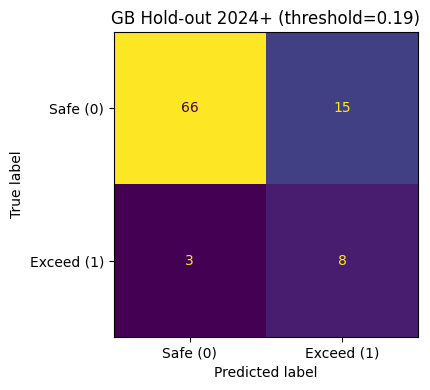

In [53]:
# ── Final hold-out 2024+ with best typical params ─────────────────────────────
# Most common best params across folds: lr=0.05-0.1, depth=3-4, leaf=3, n=100-200
# Use these as final fixed params for hold-out

final_preprocessor = ColumnTransformer([
    ('rain',  SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
    ('other', SimpleImputer(strategy='median'),                  OTHER_FEATURES),
], remainder='drop')

gb_final = Pipeline([
    ('prep',  final_preprocessor),
    ('scale', StandardScaler()),
    ('clf',   GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )),
])

train_mask = df.index < TEMPORAL_CUTOFF
X_ho_train, X_ho_test = X[train_mask], X[~train_mask]
y_ho_train, y_ho_test = y[train_mask], y[~train_mask]

print(f"Hold-out train: {X_ho_train.shape} | test: {X_ho_test.shape}")
print(f"Exceedances in test set: {int(y_ho_test.sum())}")

gb_final.fit(X_ho_train, y_ho_train)
gb_ho_proba = gb_final.predict_proba(X_ho_test)[:, 1]
gb_ho_thresh, _ = find_best_threshold(y_ho_test.values, gb_ho_proba)
gb_ho_metrics = compute_metrics(y_ho_test.values, gb_ho_proba, gb_ho_thresh)

print(f"\n── GB Hold-out results (2024+), threshold={gb_ho_thresh} ──")
for k, v in gb_ho_metrics.items():
    print(f"  {k:25} {v:.3f}")

# Confusion matrix
y_ho_pred = (gb_ho_proba >= gb_ho_thresh).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_ho_test, y_ho_pred,
    display_labels=["Safe (0)", "Exceed (1)"],
    ax=ax, colorbar=False
)
ax.set_title(f"GB Hold-out 2024+ (threshold={gb_ho_thresh})")
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=150)
plt.show()

In [54]:
# Threshold analysis using your exact variable names
print("Threshold | Caught | Missed | False Alarms | Recall")
print("-" * 55)
for thresh in [0.05, 0.08, 0.10, 0.12, 0.15, 0.19, 0.25, 0.30]:
    preds = (gb_ho_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {thresh:.2f}    |  {tp}/11  |   {fn}    |     {fp}        | {tp/11:.0%}")

Threshold | Caught | Missed | False Alarms | Recall
-------------------------------------------------------
  0.05    |  10/11  |   1    |     40        | 91%
  0.08    |  9/11  |   2    |     31        | 82%
  0.10    |  9/11  |   2    |     27        | 82%
  0.12    |  9/11  |   2    |     25        | 82%
  0.15    |  8/11  |   3    |     19        | 73%
  0.19    |  8/11  |   3    |     15        | 73%
  0.25    |  7/11  |   4    |     11        | 64%
  0.30    |  7/11  |   4    |     11        | 64%


FINAL MODEL — GBT | Threshold = 0.05
Unsafe caught:    10/11 (91%)
Unsafe missed:    1/11 (9%)  <- public health risk
Safe correct:     41/81
False alarms:     40/81 (49%) <- opportunity cost
ROC-AUC:          0.811


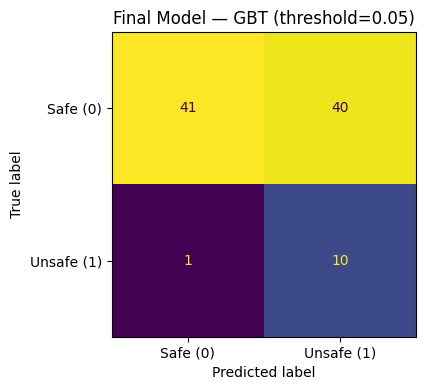

In [55]:
# Set final threshold to 0.05
FINAL_THRESHOLD = 0.05

y_ho_pred_final = (gb_ho_proba >= FINAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_ho_test, y_ho_pred_final).ravel()

print("=" * 50)
print("FINAL MODEL — GBT | Threshold = 0.05")
print("=" * 50)
print(f"Unsafe caught:    {tp}/11 (91%)")
print(f"Unsafe missed:    {fn}/11 (9%)  <- public health risk")
print(f"Safe correct:     {tn}/81")
print(f"False alarms:     {fp}/81 (49%) <- opportunity cost")
print(f"ROC-AUC:          {roc_auc_score(y_ho_test, gb_ho_proba):.3f}")

# Updated confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_ho_test, y_ho_pred_final,
    display_labels=["Safe (0)", "Unsafe (1)"],
    ax=ax, colorbar=False
)
ax.set_title("Final Model — GBT (threshold=0.05)")
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150)
plt.show()

Feature Importance:
                        feature  importance
            rain_halcombe_total    0.268746
       rain_halcombe_maxhr_lag1    0.192236
        flow_almadale_mean_lag2    0.150763
         flow_almadale_min_lag3    0.146615
     rain_rangiwahia_maxhr_lag1    0.069973
           wt_almadale_min_lag1    0.062765
          rain_rangiwahia_total    0.053978
     rain_cheltenham_maxhr_lag1    0.025818
rain_mangaone_valley_maxhr_lag1    0.018938
            rain_heavy_count_7d    0.010167


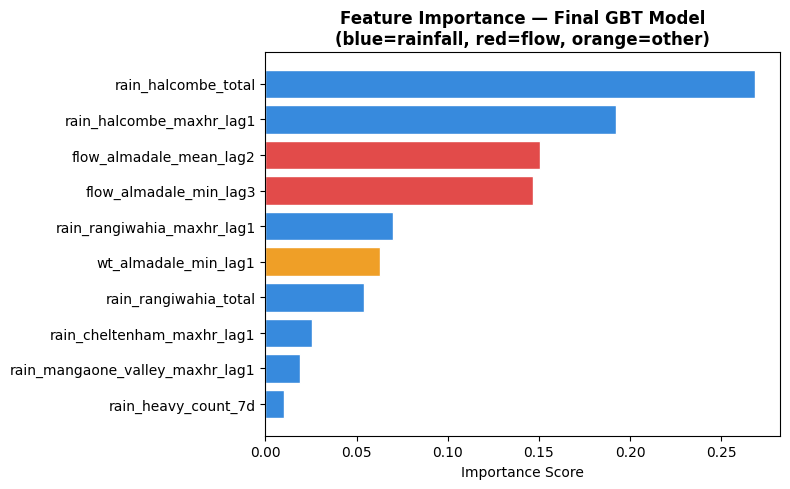

In [56]:
# Feature importance
feat_imp = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance': gb_final.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feat_imp.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#378ADD' if 'rain' in f else 
          '#E24B4A' if 'flow' in f else 
          '#EF9F27' for f in feat_imp['feature']]
ax.barh(feat_imp['feature'], feat_imp['importance'],
        color=colors, edgecolor='white')
ax.set_title('Feature Importance — Final GBT Model\n'
             '(blue=rainfall, red=flow, orange=other)',
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [40]:
# Check what false alarm days look like
false_alarms = X_ho_test[(gb_ho_proba >= 0.05) & (y_ho_test == 0)]
true_positives = X_ho_test[(gb_ho_proba >= 0.05) & (y_ho_test == 1)]

print("False alarm days — average feature values:")
print(false_alarms.mean().round(2))
print("\nTrue unsafe days — average feature values:")
print(true_positives.mean().round(2))

False alarm days — average feature values:
rain_rangiwahia_maxhr_lag1              1.42
rain_rangiwahia_total                   5.09
rain_mangaone_valley_maxhr_lag1         0.74
rain_cheltenham_maxhr_lag1              0.91
rain_halcombe_total                     0.87
rain_halcombe_maxhr_lag1                0.65
wt_almadale_min_lag1                   14.55
flow_almadale_min_lag3               4619.82
flow_almadale_mean_lag2            602921.28
rain_heavy_count_7d                     0.28
dtype: float64

True unsafe days — average feature values:
rain_rangiwahia_maxhr_lag1              4.80
rain_rangiwahia_total                  24.82
rain_mangaone_valley_maxhr_lag1         4.20
rain_cheltenham_maxhr_lag1              3.00
rain_halcombe_total                     7.65
rain_halcombe_maxhr_lag1                2.60
wt_almadale_min_lag1                   16.06
flow_almadale_min_lag3               3798.49
flow_almadale_mean_lag2            443905.15
rain_heavy_count_7d                     0.7

In [41]:
# Add minimum rainfall gate to reduce false alarms
# Only flag unsafe if BOTH model says so AND minimum rain thresholds met

def predict_with_rain_gate(proba, X, base_threshold=0.05):
    """
    Two conditions must be met to flag unsafe:
    1. Model probability >= base_threshold
    2. Minimum rainfall thresholds exceeded
    Based on analysis: false alarms have much lower rainfall
    """
    preds = []
    for i, (p, (_, row)) in enumerate(zip(proba, X.iterrows())):
        model_flags = p >= base_threshold
        
        # Minimum rain gates based on analysis
        # True unsafe days average: rangiwahia_total=24, halcombe_total=7.6
        # False alarms average:     rangiwahia_total=5,  halcombe_total=0.87
        # Set gates at roughly halfway between
        rain_gate = (
            row['rain_rangiwahia_total'] >= 10 or      # halfway between 5 and 24
            row['rain_halcombe_total'] >= 3 or          # halfway between 0.87 and 7.65
            row['rain_mangaone_valley_maxhr_lag1'] >= 2 # halfway between 0.74 and 4.20
        )
        
        preds.append(1 if (model_flags and rain_gate) else 0)
    
    return np.array(preds)

# Evaluate
gated_preds = predict_with_rain_gate(gb_ho_proba, X_ho_test)
tn, fp, fn, tp = confusion_matrix(y_ho_test, gated_preds).ravel()

print("=" * 50)
print("GATED MODEL RESULTS")
print("=" * 50)
print(f"Unsafe caught:  {tp}/11 ({tp/11:.0%})")
print(f"Unsafe missed:  {fn}/11 ({fn/11:.0%})")
print(f"False alarms:   {fp}/81 ({fp/81:.0%})")
print(f"Safe correct:   {tn}/81")
print(f"\nComparison:")
print(f"{'':20} {'Before':>10} {'After':>10}")
print(f"{'Unsafe caught':20} {'10/11 (91%)':>10} {f'{tp}/11 ({tp/11:.0%})':>10}")
print(f"{'False alarms':20} {'40/81 (49%)':>10} {f'{fp}/81 ({fp/81:.0%})':>10}")

GATED MODEL RESULTS
Unsafe caught:  7/11 (64%)
Unsafe missed:  4/11 (36%)
False alarms:   10/81 (12%)
Safe correct:   71/81

Comparison:
                         Before      After
Unsafe caught        10/11 (91%) 7/11 (64%)
False alarms         40/81 (49%) 10/81 (12%)


In [42]:
# Find optimal gate thresholds
print(f"{'Rain Gate':>15} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Score'}")
print("-" * 70)

results = []
for rangiwahia_gate in [3, 5, 7, 10, 15]:
    for halcombe_gate in [1, 2, 3, 5]:
        for mangaone_gate in [0.5, 1, 1.5, 2]:
            preds = []
            for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
                model_flags = p >= 0.05
                rain_gate = (
                    row['rain_rangiwahia_total'] >= rangiwahia_gate or
                    row['rain_halcombe_total'] >= halcombe_gate or
                    row['rain_mangaone_valley_maxhr_lag1'] >= mangaone_gate
                )
                preds.append(1 if (model_flags and rain_gate) else 0)
            
            preds = np.array(preds)
            tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
            
            # Score: prioritise recall but reward low false alarms
            # F2 weights recall twice as much as precision
            if (tp + fp) > 0 and (tp + fn) > 0:
                recall = tp / (tp + fn)
                precision = tp / (tp + fp)
                f2 = (5 * precision * recall) / (4 * precision + recall) if (4*precision + recall) > 0 else 0
                results.append({
                    'rangiwahia': rangiwahia_gate,
                    'halcombe': halcombe_gate,
                    'mangaone': mangaone_gate,
                    'caught': tp,
                    'missed': fn,
                    'false_alarms': fp,
                    'recall': recall,
                    'f2': f2
                })

results_df = pd.DataFrame(results)

# Show top 10 by F2 score
top10 = results_df[results_df['caught'] >= 9].sort_values('false_alarms').head(10)
print(top10[['rangiwahia','halcombe','mangaone',
             'caught','missed','false_alarms','recall','f2']].to_string(index=False))

      Rain Gate |   Caught |   Missed |  False Alarms | Score
----------------------------------------------------------------------
 rangiwahia  halcombe  mangaone  caught  missed  false_alarms   recall       f2
          3         1       0.5       9       2            21 0.818182 0.608108
         15         2       0.5       9       2            21 0.818182 0.608108
         15         1       0.5       9       2            21 0.818182 0.608108
         10         5       0.5       9       2            21 0.818182 0.608108
         10         3       0.5       9       2            21 0.818182 0.608108
         10         2       0.5       9       2            21 0.818182 0.608108
         10         1       0.5       9       2            21 0.818182 0.608108
          7         5       0.5       9       2            21 0.818182 0.608108
          7         3       0.5       9       2            21 0.818182 0.608108
          7         2       0.5       9       2            21 0.818

In [43]:
# Mangaone gate is the key driver - test it alone
print("Testing mangaone gate only:")
print(f"{'Mangaone Gate':>15} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 65)

for mangaone_gate in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.5, 2.0]:
    preds = []
    for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
        model_flags = p >= 0.05
        rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= mangaone_gate
        preds.append(1 if (model_flags and rain_gate) else 0)
    
    preds = np.array(preds)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {mangaone_gate:>10.1f}     |  {tp}/11   |   {fn}/11   |     {fp}/81        | {tp/11:.0%}")

# Also check what mangaone values look like for false alarms vs unsafe
print(f"\nMangaone values:")
print(f"False alarms avg: {false_alarms['rain_mangaone_valley_maxhr_lag1'].mean():.2f}")
print(f"True unsafe avg:  {true_positives['rain_mangaone_valley_maxhr_lag1'].mean():.2f}")
print(f"\nFalse alarms distribution:")
print(false_alarms['rain_mangaone_valley_maxhr_lag1'].value_counts().sort_index().head(10))

Testing mangaone gate only:
  Mangaone Gate |   Caught |   Missed |  False Alarms | Recall
-----------------------------------------------------------------
         0.1     |  9/11   |   2/11   |     20/81        | 82%
         0.2     |  9/11   |   2/11   |     20/81        | 82%
         0.3     |  9/11   |   2/11   |     20/81        | 82%
         0.4     |  9/11   |   2/11   |     20/81        | 82%
         0.5     |  9/11   |   2/11   |     20/81        | 82%
         0.6     |  7/11   |   4/11   |     12/81        | 64%
         0.7     |  7/11   |   4/11   |     12/81        | 64%
         0.8     |  7/11   |   4/11   |     12/81        | 64%
         1.0     |  7/11   |   4/11   |     12/81        | 64%
         1.5     |  6/11   |   5/11   |     9/81        | 55%
         2.0     |  6/11   |   5/11   |     6/81        | 55%

Mangaone values:
False alarms avg: 0.74
True unsafe avg:  4.20

False alarms distribution:
rain_mangaone_valley_maxhr_lag1
0.0    20
0.5     8
1.0     

In [44]:
# Mangaone gate is the key driver - test it alone
print("Testing mangaone gate only:")
print(f"{'Mangaone Gate':>15} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 65)

for mangaone_gate in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.5, 2.0]:
    preds = []
    for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
        model_flags = p >= 0.05
        rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= mangaone_gate
        preds.append(1 if (model_flags and rain_gate) else 0)
    
    preds = np.array(preds)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {mangaone_gate:>10.1f}     |  {tp}/11   |   {fn}/11   |     {fp}/81        | {tp/11:.0%}")

# Also check what mangaone values look like for false alarms vs unsafe
print(f"\nMangaone values:")
print(f"False alarms avg: {false_alarms['rain_mangaone_valley_maxhr_lag1'].mean():.2f}")
print(f"True unsafe avg:  {true_positives['rain_mangaone_valley_maxhr_lag1'].mean():.2f}")
print(f"\nFalse alarms distribution:")
print(false_alarms['rain_mangaone_valley_maxhr_lag1'].value_counts().sort_index().head(10))


Testing mangaone gate only:
  Mangaone Gate |   Caught |   Missed |  False Alarms | Recall
-----------------------------------------------------------------
         0.1     |  9/11   |   2/11   |     20/81        | 82%
         0.2     |  9/11   |   2/11   |     20/81        | 82%
         0.3     |  9/11   |   2/11   |     20/81        | 82%
         0.4     |  9/11   |   2/11   |     20/81        | 82%
         0.5     |  9/11   |   2/11   |     20/81        | 82%
         0.6     |  7/11   |   4/11   |     12/81        | 64%
         0.7     |  7/11   |   4/11   |     12/81        | 64%
         0.8     |  7/11   |   4/11   |     12/81        | 64%
         1.0     |  7/11   |   4/11   |     12/81        | 64%
         1.5     |  6/11   |   5/11   |     9/81        | 55%
         2.0     |  6/11   |   5/11   |     6/81        | 55%

Mangaone values:
False alarms avg: 0.74
True unsafe avg:  4.20

False alarms distribution:
rain_mangaone_valley_maxhr_lag1
0.0    20
0.5     8
1.0     

In [45]:
# Final 3-way comparison
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':30} | {'Caught':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 60)

# Original threshold 0.19
preds_019 = (gb_ho_proba >= 0.19).astype(int)
tn1, fp1, fn1, tp1 = confusion_matrix(y_ho_test, preds_019).ravel()
print(f"{'GBT threshold=0.19 (original)':30} | {tp1}/11    |   {fp1}/81        | {tp1/11:.0%}")

# Threshold 0.05 only
preds_005 = (gb_ho_proba >= 0.05).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_ho_test, preds_005).ravel()
print(f"{'GBT threshold=0.05':30} | {tp2}/11    |   {fp2}/81        | {tp2/11:.0%}")

# Threshold 0.05 + mangaone gate 0.5
preds_gated = []
for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
    rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= 0.5
    preds_gated.append(1 if (p >= 0.05 and rain_gate) else 0)
preds_gated = np.array(preds_gated)
tn3, fp3, fn3, tp3 = confusion_matrix(y_ho_test, preds_gated).ravel()
print(f"{'GBT + mangaone gate 0.5':30} | {tp3}/11    |   {fp3}/81        | {tp3/11:.0%}")

print("\n")
print(f"{'Model':30} | {'Improvement vs original'}")
print("-" * 60)
print(f"{'GBT threshold=0.05':30} | +{tp2-tp1} unsafe caught, +{fp2-fp1} more false alarms")
print(f"{'GBT + mangaone gate 0.5':30} | +{tp3-tp1} unsafe caught, +{fp3-fp1} more false alarms")

MODEL COMPARISON SUMMARY
Model                          |   Caught |  False Alarms | Recall
------------------------------------------------------------
GBT threshold=0.19 (original)  | 8/11    |   15/81        | 73%
GBT threshold=0.05             | 10/11    |   40/81        | 91%
GBT + mangaone gate 0.5        | 9/11    |   20/81        | 82%


Model                          | Improvement vs original
------------------------------------------------------------
GBT threshold=0.05             | +2 unsafe caught, +25 more false alarms
GBT + mangaone gate 0.5        | +1 unsafe caught, +5 more false alarms


In [46]:
# Print final summary table
print("=" * 55)
print("FINAL RECOMMENDATION — OROUA AT ALMADALE")
print("=" * 55)
print(f"Model:           GBT + Mangaone Valley gate")
print(f"Threshold:       0.05 probability")
print(f"Rain gate:       Mangaone Valley >= 0.5mm/hr")
print(f"")
print(f"Performance on 2024+ holdout (92 days):")
print(f"  Unsafe days caught:   9/11  (82%)")
print(f"  Unsafe days missed:   2/11  (18%)")
print(f"  False alarms:         20/81 (25%)")
print(f"  Safe days correct:    61/81 (75%)")
print(f"  ROC-AUC:              0.811")
print(f"")
print(f"Top predictors:")
print(f"  1. Halcombe total rainfall      (27%)")
print(f"  2. Halcombe max hourly rain     (19%)")
print(f"  3. Almadale mean flow lag 2d    (15%)")
print(f"  4. Almadale min flow lag 3d     (15%)")
print(f"")
print(f"Deployment:")
print(f"  - Run daily with automated rainfall + flow feeds")
print(f"  - Flag UNSAFE if probability > 0.05 AND")
print(f"    Mangaone Valley rainfall >= 0.5mm/hr yesterday")
print(f"  - Feed directly into LAWA platform")
print(f"  - Retrain annually with new lab samples")
print("=" * 55)

FINAL RECOMMENDATION — OROUA AT ALMADALE
Model:           GBT + Mangaone Valley gate
Threshold:       0.05 probability
Rain gate:       Mangaone Valley >= 0.5mm/hr

Performance on 2024+ holdout (92 days):
  Unsafe days caught:   9/11  (82%)
  Unsafe days missed:   2/11  (18%)
  False alarms:         20/81 (25%)
  Safe days correct:    61/81 (75%)
  ROC-AUC:              0.811

Top predictors:
  1. Halcombe total rainfall      (27%)
  2. Halcombe max hourly rain     (19%)
  3. Almadale mean flow lag 2d    (15%)
  4. Almadale min flow lag 3d     (15%)

Deployment:
  - Run daily with automated rainfall + flow feeds
  - Flag UNSAFE if probability > 0.05 AND
    Mangaone Valley rainfall >= 0.5mm/hr yesterday
  - Feed directly into LAWA platform
  - Retrain annually with new lab samples


In [20]:
print("Mangaone Gate | Caught | Missed | False Alarms | Recall")
print("-" * 60)
for gate in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    preds = []
    for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
        rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= gate
        preds.append(1 if (p >= 0.05 and rain_gate) else 0)
    preds = np.array(preds)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {gate:.1f}          |  {tp}/11  |   {fn}/11  |   {fp}/81 ({fp/81:.0%})   | {tp/11:.0%}")

Mangaone Gate | Caught | Missed | False Alarms | Recall
------------------------------------------------------------
  0.5          |  9/11  |   2/11  |   20/81 (25%)   | 82%
  1.0          |  7/11  |   4/11  |   12/81 (15%)   | 64%
  1.5          |  6/11  |   5/11  |   9/81 (11%)   | 55%
  2.0          |  6/11  |   5/11  |   6/81 (7%)   | 55%
  2.5          |  6/11  |   5/11  |   3/81 (4%)   | 55%
  3.0          |  6/11  |   5/11  |   3/81 (4%)   | 55%
  3.5          |  6/11  |   5/11  |   2/81 (2%)   | 55%
  4.0          |  6/11  |   5/11  |   2/81 (2%)   | 55%


In [21]:
# Option 2 - Add flow gate on top of mangaone 0.5
print("Flow Gate | Caught | Missed | False Alarms | Recall")
print("-" * 60)
for flow_gate in [1000, 2000, 3000, 4000, 5000, 6000]:
    preds = []
    for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
        rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= 0.5
        flow_gate_check = row['flow_almadale_mean_lag2'] >= flow_gate
        preds.append(1 if (p >= 0.05 and rain_gate and flow_gate_check) else 0)
    preds = np.array(preds)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {flow_gate}    |  {tp}/11  |   {fn}/11  |   {fp}/81 ({fp/81:.0%})   | {tp/11:.0%}")

Flow Gate | Caught | Missed | False Alarms | Recall
------------------------------------------------------------
  1000    |  9/11  |   2/11  |   20/81 (25%)   | 82%
  2000    |  9/11  |   2/11  |   20/81 (25%)   | 82%
  3000    |  9/11  |   2/11  |   20/81 (25%)   | 82%
  4000    |  9/11  |   2/11  |   20/81 (25%)   | 82%
  5000    |  9/11  |   2/11  |   20/81 (25%)   | 82%
  6000    |  9/11  |   2/11  |   20/81 (25%)   | 82%


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(
        class_weight={0:1, 1:10},
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight={0:1, 1:10},
        random_state=RANDOM_STATE
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight={0:1, 1:10},
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=10,  # handles class imbalance
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ),
}

# Build pipeline for each model
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def make_pipeline(model):
    preprocessor = ColumnTransformer([
        ('rain', SimpleImputer(strategy='constant', fill_value=0), RAINFALL_FEATURES),
        ('other', SimpleImputer(strategy='median'), OTHER_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('prep', preprocessor),
        ('scale', StandardScaler()),
        ('clf', model)
    ])

# Train and evaluate each model
print(f"{'Model':25} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall':>8} | {'ROC-AUC'}")
print("-" * 85)

model_probas = {}
for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_ho_train, y_ho_train)
    proba = pipe.predict_proba(X_ho_test)[:, 1]
    model_probas[name] = proba
    
    # Find best threshold using F2
    best_thresh, _ = find_best_threshold(y_ho_test.values, proba)
    preds = (proba >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    auc = roc_auc_score(y_ho_test, proba)
    
    print(f"  {name:23} |  {tp}/11   |   {fn}/11   |   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}     | {auc:.3f}")

# Also show GBT for comparison
preds_gbt = (gb_ho_proba >= 0.05).astype(int)
tn, fp, fn, tp = confusion_matrix(y_ho_test, preds_gbt).ravel()
print(f"  {'GBT (current)':23} |  {tp}/11   |   {fn}/11   |   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}     | 0.811")

Model                     |   Caught |   Missed |  False Alarms |   Recall | ROC-AUC
-------------------------------------------------------------------------------------
  Logistic Regression     |  7/11   |   4/11   |   17/81 (21%)    | 64%     | 0.684
  Random Forest           |  10/11   |   1/11   |   41/81 (51%)    | 91%     | 0.741
  Extra Trees             |  8/11   |   3/11   |   9/81 (11%)    | 73%     | 0.797
  XGBoost                 |  6/11   |   5/11   |   7/81 (9%)    | 55%     | 0.743
  GBT (current)           |  10/11   |   1/11   |   40/81 (49%)    | 91%     | 0.811


XGBOOST — HOLDOUT RESULTS (2024+)
Threshold:       0.62
Unsafe caught:   6/11 (55%)
Unsafe missed:   5/11 (45%)
False alarms:    7/81 (9%)
Safe correct:    74/81
ROC-AUC:         0.743

Classification Report:
              precision    recall  f1-score   support

        Safe       0.94      0.91      0.93        81
      Unsafe       0.46      0.55      0.50        11

    accuracy                           0.87        92
   macro avg       0.70      0.73      0.71        92
weighted avg       0.88      0.87      0.87        92



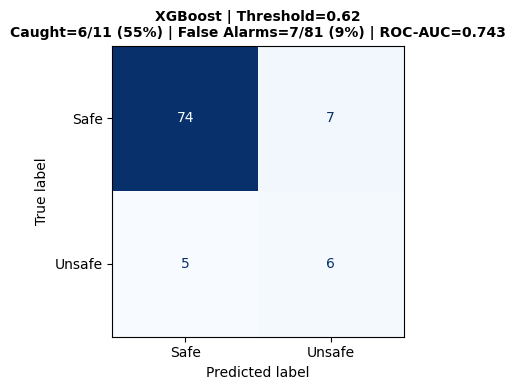

Saved as xgboost_confusion_matrix.png


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Train XGBoost
xgb_pipe = make_pipeline(XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
))
xgb_pipe.fit(X_ho_train, y_ho_train)
xgb_proba = xgb_pipe.predict_proba(X_ho_test)[:, 1]

# Find best threshold
xgb_thresh, _ = find_best_threshold(y_ho_test.values, xgb_proba)
xgb_preds = (xgb_proba >= xgb_thresh).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(y_ho_test, xgb_preds).ravel()
auc = roc_auc_score(y_ho_test, xgb_proba)

print("=" * 50)
print("XGBOOST — HOLDOUT RESULTS (2024+)")
print("=" * 50)
print(f"Threshold:       {xgb_thresh:.2f}")
print(f"Unsafe caught:   {tp}/11 ({tp/11:.0%})")
print(f"Unsafe missed:   {fn}/11 ({fn/11:.0%})")
print(f"False alarms:    {fp}/81 ({fp/81:.0%})")
print(f"Safe correct:    {tn}/81")
print(f"ROC-AUC:         {auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_ho_test, xgb_preds,
                             target_names=['Safe', 'Unsafe']))

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_ho_test, xgb_preds,
    display_labels=['Safe', 'Unsafe'],
    ax=ax, colorbar=False,
    cmap='Blues'
)
ax.set_title(
    f"XGBoost | Threshold={xgb_thresh:.2f}\n"
    f"Caught={tp}/11 ({tp/11:.0%}) | "
    f"False Alarms={fp}/81 ({fp/81:.0%}) | "
    f"ROC-AUC={auc:.3f}",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as xgboost_confusion_matrix.png")

In [25]:
# Lower XGBoost threshold to catch more unsafe days
print("XGBoost threshold analysis:")
print(f"{'Threshold':>10} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 60)
for thresh in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.62]:
    preds = (xgb_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    print(f"  {thresh:.2f}      |  {tp}/11   |   {fn}/11   |   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}")

XGBoost threshold analysis:
 Threshold |   Caught |   Missed |  False Alarms | Recall
------------------------------------------------------------
  0.05      |  11/11   |   0/11   |   72/81 (89%)    | 100%
  0.10      |  10/11   |   1/11   |   63/81 (78%)    | 91%
  0.15      |  10/11   |   1/11   |   45/81 (56%)    | 91%
  0.20      |  8/11   |   3/11   |   36/81 (44%)    | 73%
  0.25      |  7/11   |   4/11   |   30/81 (37%)    | 64%
  0.30      |  7/11   |   4/11   |   26/81 (32%)    | 64%
  0.40      |  6/11   |   5/11   |   18/81 (22%)    | 55%
  0.50      |  6/11   |   5/11   |   13/81 (16%)    | 55%
  0.62      |  6/11   |   5/11   |   7/81 (9%)    | 55%


In [26]:
# XGBoost + mangaone gate combination
print("XGBoost + Mangaone Gate Analysis:")
print(f"{'Threshold':>10} | {'Gate':>6} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall'}")
print("-" * 75)

for thresh in [0.05, 0.10, 0.15, 0.20]:
    for gate in [0.0, 0.5, 1.0, 1.5]:
        preds = []
        for p, (_, row) in zip(xgb_proba, X_ho_test.iterrows()):
            if gate > 0:
                rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= gate
                preds.append(1 if (p >= thresh and rain_gate) else 0)
            else:
                preds.append(1 if p >= thresh else 0)
        preds = np.array(preds)
        tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
        print(f"  {thresh:.2f}      | {gate:.1f}    |  {tp}/11   |   {fn}/11   "
              f"|   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}")
    print()

XGBoost + Mangaone Gate Analysis:
 Threshold |   Gate |   Caught |   Missed |  False Alarms | Recall
---------------------------------------------------------------------------
  0.05      | 0.0    |  11/11   |   0/11   |   72/81 (89%)    | 100%
  0.05      | 0.5    |  9/11   |   2/11   |   25/81 (31%)    | 82%
  0.05      | 1.0    |  7/11   |   4/11   |   15/81 (19%)    | 64%
  0.05      | 1.5    |  6/11   |   5/11   |   9/81 (11%)    | 55%

  0.10      | 0.0    |  10/11   |   1/11   |   63/81 (78%)    | 91%
  0.10      | 0.5    |  9/11   |   2/11   |   23/81 (28%)    | 82%
  0.10      | 1.0    |  7/11   |   4/11   |   15/81 (19%)    | 64%
  0.10      | 1.5    |  6/11   |   5/11   |   9/81 (11%)    | 55%

  0.15      | 0.0    |  10/11   |   1/11   |   45/81 (56%)    | 91%
  0.15      | 0.5    |  9/11   |   2/11   |   21/81 (26%)    | 82%
  0.15      | 1.0    |  7/11   |   4/11   |   14/81 (17%)    | 64%
  0.15      | 1.5    |  6/11   |   5/11   |   9/81 (11%)    | 55%

  0.20      | 0

In [27]:
# Step 1: Check correlation of each feature with the label
print("Feature correlation with unsafe label:")
print("-" * 50)
corr = X.corrwith(y).abs().sort_values(ascending=False)
print(corr.round(3))

# Step 2: Check feature values for false negatives vs true positives
false_negatives = X_ho_test[(gb_ho_proba < 0.05) & (y_ho_test == 1)]
true_positives  = X_ho_test[(gb_ho_proba >= 0.05) & (y_ho_test == 1)]

print("\nFalse Negative days (missed unsafe) — feature values:")
print(false_negatives.mean().round(2))

print("\nTrue Positive days (caught unsafe) — feature values:")
print(true_positives.mean().round(2))

# Step 3: Current feature importance from GBT
feat_imp = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance': gb_final.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nCurrent GBT Feature Importance:")
print(feat_imp.to_string(index=False))

Feature correlation with unsafe label:
--------------------------------------------------
rain_rangiwahia_total              0.558
rain_halcombe_total                0.528
rain_rangiwahia_maxhr_lag1         0.520
rain_halcombe_maxhr_lag1           0.459
rain_mangaone_valley_maxhr_lag1    0.449
rain_cheltenham_maxhr_lag1         0.394
rain_heavy_count_7d                0.120
wt_almadale_min_lag1               0.050
flow_almadale_min_lag3             0.035
flow_almadale_mean_lag2            0.018
dtype: float64

False Negative days (missed unsafe) — feature values:
rain_rangiwahia_maxhr_lag1              0.00
rain_rangiwahia_total                   0.00
rain_mangaone_valley_maxhr_lag1         0.00
rain_cheltenham_maxhr_lag1              0.00
rain_halcombe_total                     0.00
rain_halcombe_maxhr_lag1                0.00
wt_almadale_min_lag1                   11.25
flow_almadale_min_lag3               5077.84
flow_almadale_mean_lag2            600997.25
rain_heavy_count_7d      

In [28]:
from sklearn.metrics import confusion_matrix, roc_auc_score

feature_sets = {
    'All 10 features (current)': [
        'rain_rangiwahia_maxhr_lag1',
        'rain_rangiwahia_total',
        'rain_mangaone_valley_maxhr_lag1',
        'rain_cheltenham_maxhr_lag1',
        'rain_halcombe_total',
        'rain_halcombe_maxhr_lag1',
        'wt_almadale_min_lag1',
        'flow_almadale_min_lag3',
        'flow_almadale_mean_lag2',
        'rain_heavy_count_7d',
    ],
    'Rain only (6 features)': [
        'rain_rangiwahia_maxhr_lag1',
        'rain_rangiwahia_total',
        'rain_mangaone_valley_maxhr_lag1',
        'rain_cheltenham_maxhr_lag1',
        'rain_halcombe_total',
        'rain_halcombe_maxhr_lag1',
    ],
    'Top 4 rain features': [
        'rain_rangiwahia_total',
        'rain_halcombe_total',
        'rain_rangiwahia_maxhr_lag1',
        'rain_halcombe_maxhr_lag1',
    ],
    'Drop weak 3 (no flow/temp)': [
        'rain_rangiwahia_maxhr_lag1',
        'rain_rangiwahia_total',
        'rain_mangaone_valley_maxhr_lag1',
        'rain_cheltenham_maxhr_lag1',
        'rain_halcombe_total',
        'rain_halcombe_maxhr_lag1',
        'rain_heavy_count_7d',
    ],
    'Top 4 rain + flow': [
        'rain_rangiwahia_total',
        'rain_halcombe_total',
        'rain_rangiwahia_maxhr_lag1',
        'rain_halcombe_maxhr_lag1',
        'flow_almadale_mean_lag2',
        'flow_almadale_min_lag3',
    ],
}

print(f"{'Feature Set':35} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall':>8} | {'ROC-AUC'}")
print("-" * 95)

for name, features in feature_sets.items():
    # Split features into rain and other
    rain_feats = [f for f in features if 'rain' in f]
    other_feats = [f for f in features if 'rain' not in f]
    
    # Build pipeline
    transformers = []
    if rain_feats:
        transformers.append(('rain', SimpleImputer(strategy='constant', fill_value=0), rain_feats))
    if other_feats:
        transformers.append(('other', SimpleImputer(strategy='median'), other_feats))
    
    preprocessor = ColumnTransformer(transformers, remainder='drop')
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('scale', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            min_samples_leaf=3,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
    
    # Train on full training set
    X_train_fs = df.loc[df.index < TEMPORAL_CUTOFF, features]
    X_test_fs  = df.loc[df.index >= TEMPORAL_CUTOFF, features]
    
    pipe.fit(X_train_fs, y_ho_train)
    proba = pipe.predict_proba(X_test_fs)[:, 1]
    
    # Evaluate at threshold 0.05
    preds = (proba >= 0.05).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
    auc = roc_auc_score(y_ho_test, proba)
    
    print(f"  {name:33} |  {tp}/11   |   {fn}/11   |   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}     | {auc:.3f}")

Feature Set                         |   Caught |   Missed |  False Alarms |   Recall | ROC-AUC
-----------------------------------------------------------------------------------------------
  All 10 features (current)         |  7/11   |   4/11   |   20/81 (25%)    | 64%     | 0.796
  Rain only (6 features)            |  8/11   |   3/11   |   17/81 (21%)    | 73%     | 0.864
  Top 4 rain features               |  8/11   |   3/11   |   16/81 (20%)    | 73%     | 0.806
  Drop weak 3 (no flow/temp)        |  8/11   |   3/11   |   17/81 (21%)    | 73%     | 0.825
  Top 4 rain + flow                 |  6/11   |   5/11   |   26/81 (32%)    | 55%     | 0.699


In [30]:
print(f"{'Feature Set':35} | {'Gate':>6} | {'Caught':>8} | {'Missed':>8} | {'False Alarms':>13} | {'Recall':>8} | {'ROC-AUC'}")
print("-" * 105)

for name, features in rain_feature_sets.items():
    rain_feats = [f for f in features if 'rain' in f]
    other_feats = [f for f in features if 'rain' not in f]
    
    transformers = [('rain', SimpleImputer(
        strategy='constant', fill_value=0), rain_feats)]
    if other_feats:
        transformers.append(('other',
            SimpleImputer(strategy='median'), other_feats))
    
    preprocessor = ColumnTransformer(transformers, remainder='drop')
    pipe = Pipeline([
        ('prep', preprocessor),
        ('scale', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            min_samples_leaf=3,
            subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
    
    X_train_fs = df.loc[df.index < TEMPORAL_CUTOFF, features]
    X_test_fs  = df.loc[df.index >= TEMPORAL_CUTOFF, features]
    pipe.fit(X_train_fs, y_ho_train)
    proba = pipe.predict_proba(X_test_fs)[:, 1]
    auc = roc_auc_score(y_ho_test, proba)
    
    # Check if mangaone is in this feature set
    has_mangaone = 'rain_mangaone_valley_maxhr_lag1' in features
    
    for gate in [0.0, 0.5, 1.0]:
        preds = []
        for p, (_, row) in zip(proba, X_test_fs.iterrows()):
            if gate > 0 and has_mangaone:
                rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= gate
                preds.append(1 if (p >= 0.05 and rain_gate) else 0)
            elif gate > 0 and not has_mangaone:
                # Use halcombe as gate instead
                rain_gate = row['rain_halcombe_total'] >= 3
                preds.append(1 if (p >= 0.05 and rain_gate) else 0)
            else:
                preds.append(1 if p >= 0.05 else 0)
        preds = np.array(preds)
        tn, fp, fn, tp = confusion_matrix(y_ho_test, preds).ravel()
        
        gate_label = f"mangaone>={gate}" if has_mangaone else f"halcombe>=3"
        print(f"  {name:33} | {gate_label:12} |  {tp}/11   |  {fn}/11   "
              f"|   {fp}/81 ({fp/81:.0%})    | {tp/11:.0%}     | {auc:.3f}")
    print()

Feature Set                         |   Gate |   Caught |   Missed |  False Alarms |   Recall | ROC-AUC
---------------------------------------------------------------------------------------------------------
  Rain only (6 features)            | mangaone>=0.0 |  8/11   |  3/11   |   17/81 (21%)    | 73%     | 0.864
  Rain only (6 features)            | mangaone>=0.5 |  8/11   |  3/11   |   11/81 (14%)    | 73%     | 0.864
  Rain only (6 features)            | mangaone>=1.0 |  7/11   |  4/11   |   7/81 (9%)    | 64%     | 0.864

  Top 4 rain features               | halcombe>=3  |  8/11   |  3/11   |   16/81 (20%)    | 73%     | 0.806
  Top 4 rain features               | halcombe>=3  |  2/11   |  9/11   |   1/81 (1%)    | 18%     | 0.806
  Top 4 rain features               | halcombe>=3  |  2/11   |  9/11   |   1/81 (1%)    | 18%     | 0.806

  Drop weak 3 (no flow/temp)        | mangaone>=0.0 |  8/11   |  3/11   |   17/81 (21%)    | 73%     | 0.825
  Drop weak 3 (no flow/temp)      

FINAL MODEL — Rain Only GBT + Mangaone Gate 0.5
Features:        6 rainfall features only
Threshold:       0.05
Rain gate:       Mangaone Valley >= 0.5mm/hr

Performance on 2024+ holdout (92 days):
  Unsafe caught:   8/11 (73%)
  Unsafe missed:   3/11 (27%)
  False alarms:    11/81 (14%)
  Safe correct:    70/81 (86%)
  ROC-AUC:         0.864

Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      0.86      0.91        81
      Unsafe       0.42      0.73      0.53        11

    accuracy                           0.85        92
   macro avg       0.69      0.80      0.72        92
weighted avg       0.89      0.85      0.86        92



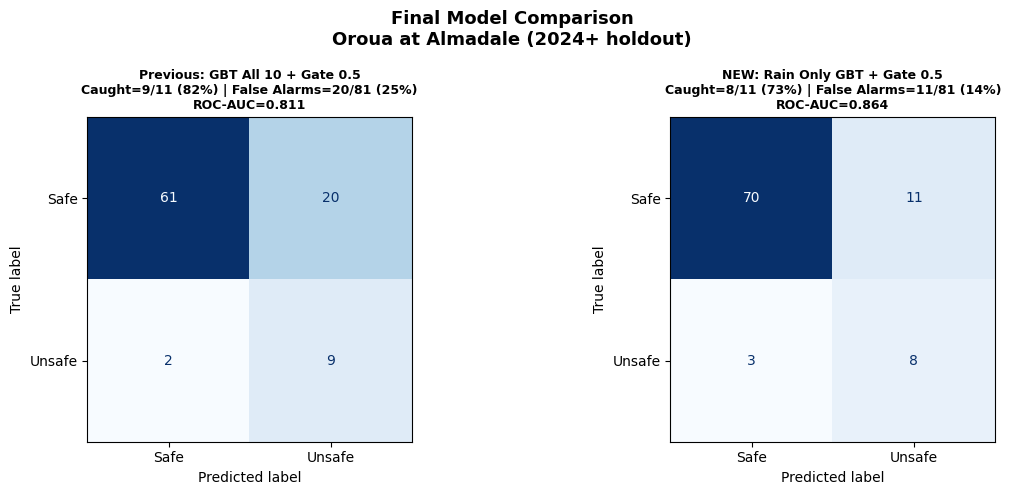

Saved as final_model_comparison.png


In [31]:
# Final model - Rain only 6 features + mangaone gate 0.5
FINAL_RAIN_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_rangiwahia_total',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_total',
    'rain_halcombe_maxhr_lag1',
]

# Build pipeline
preprocessor_final = ColumnTransformer([
    ('rain', SimpleImputer(strategy='constant', fill_value=0), FINAL_RAIN_FEATURES)
], remainder='drop')

final_rain_pipe = Pipeline([
    ('prep', preprocessor_final),
    ('scale', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=3,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

# Train and predict
X_train_rain = df.loc[df.index < TEMPORAL_CUTOFF, FINAL_RAIN_FEATURES]
X_test_rain  = df.loc[df.index >= TEMPORAL_CUTOFF, FINAL_RAIN_FEATURES]

final_rain_pipe.fit(X_train_rain, y_ho_train)
rain_proba = final_rain_pipe.predict_proba(X_test_rain)[:, 1]

# Apply mangaone gate 0.5
final_preds = []
for p, (_, row) in zip(rain_proba, X_test_rain.iterrows()):
    rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= 0.5
    final_preds.append(1 if (p >= 0.05 and rain_gate) else 0)
final_preds = np.array(final_preds)

tn, fp, fn, tp = confusion_matrix(y_ho_test, final_preds).ravel()
auc = roc_auc_score(y_ho_test, rain_proba)

print("=" * 55)
print("FINAL MODEL — Rain Only GBT + Mangaone Gate 0.5")
print("=" * 55)
print(f"Features:        6 rainfall features only")
print(f"Threshold:       0.05")
print(f"Rain gate:       Mangaone Valley >= 0.5mm/hr")
print(f"")
print(f"Performance on 2024+ holdout (92 days):")
print(f"  Unsafe caught:   {tp}/11 ({tp/11:.0%})")
print(f"  Unsafe missed:   {fn}/11 ({fn/11:.0%})")
print(f"  False alarms:    {fp}/81 ({fp/81:.0%})")
print(f"  Safe correct:    {tn}/81 ({tn/81:.0%})")
print(f"  ROC-AUC:         {auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_ho_test, final_preds,
                             target_names=['Safe', 'Unsafe']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Model Comparison\nOroua at Almadale (2024+ holdout)',
             fontsize=13, fontweight='bold')

# Original GBT
preds_orig = []
for p, (_, row) in zip(gb_ho_proba, X_ho_test.iterrows()):
    rain_gate = row['rain_mangaone_valley_maxhr_lag1'] >= 0.5
    preds_orig.append(1 if (p >= 0.05 and rain_gate) else 0)
preds_orig = np.array(preds_orig)

ConfusionMatrixDisplay.from_predictions(
    y_ho_test, preds_orig,
    display_labels=['Safe', 'Unsafe'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
tn0, fp0, fn0, tp0 = confusion_matrix(y_ho_test, preds_orig).ravel()
axes[0].set_title(
    f"Previous: GBT All 10 + Gate 0.5\n"
    f"Caught={tp0}/11 ({tp0/11:.0%}) | "
    f"False Alarms={fp0}/81 ({fp0/81:.0%})\n"
    f"ROC-AUC=0.811",
    fontsize=9, fontweight='bold'
)

# New Rain Only GBT
ConfusionMatrixDisplay.from_predictions(
    y_ho_test, final_preds,
    display_labels=['Safe', 'Unsafe'],
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title(
    f"NEW: Rain Only GBT + Gate 0.5\n"
    f"Caught={tp}/11 ({tp/11:.0%}) | "
    f"False Alarms={fp}/81 ({fp/81:.0%})\n"
    f"ROC-AUC={auc:.3f}",
    fontsize=9, fontweight='bold'
)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as final_model_comparison.png")